In [1]:
import pandas as pd

In [2]:
demographics = pd.read_csv("C:/Users/Aadhi/Downloads/ml_project/data/raw/Telco_customer_churn_demographics.csv")
services = pd.read_csv("C:/Users/Aadhi/Downloads/ml_project/data/raw/Telco_customer_churn_services.csv")
status = pd.read_csv("C:/Users/Aadhi/Downloads/ml_project/data/raw/Telco_customer_churn_status.csv")
location = pd.read_csv("C:/Users/Aadhi/Downloads/ml_project/data/raw/Telco_customer_churn_location.csv")
population = pd.read_csv("C:/Users/Aadhi/Downloads/ml_project/data/raw/Telco_customer_churn_population.csv")

In [3]:
datasets = {
    "demographics": demographics,
    "services": services,
    "status": status,
    "location": location,
    "population": population
}

for name1, df1 in datasets.items():
    for name2, df2 in datasets.items():
        if name1 < name2:
            common = set(df1.columns) & set(df2.columns)

            if common:
                print(f"{name1} + {name2}:")
                print(common)
                print()

demographics + services:
{'Count', 'Customer ID'}

demographics + status:
{'Count', 'Customer ID'}

demographics + location:
{'Count', 'Customer ID'}

services + status:
{'Quarter', 'Count', 'Customer ID'}

location + services:
{'Count', 'Customer ID'}

location + status:
{'Count', 'Customer ID'}

location + population:
{'Zip Code'}



In [4]:
print("Demographics duplicates:",
      demographics["Customer ID"].duplicated().sum())

print("Services duplicates:",
      services["Customer ID"].duplicated().sum())

print("Status duplicates:",
      status["Customer ID"].duplicated().sum())

print("Location duplicates:",
      location["Customer ID"].duplicated().sum())

print("Population Zip Code duplicates:",
      population["Zip Code"].duplicated().sum())

Demographics duplicates: 0
Services duplicates: 0
Status duplicates: 0
Location duplicates: 0
Population Zip Code duplicates: 0


In [5]:
print("Demographics:", demographics.shape)
print("Services:", services.shape)
print("Status:", status.shape)
print("Location:", location.shape)
print("Population:", population.shape)

Demographics: (7043, 9)
Services: (7043, 31)
Status: (7043, 12)
Location: (7043, 10)
Population: (1671, 3)


In [6]:
# 1. Demographics + Services
combined = demographics.merge(
    services,
    on="Customer ID",
    how="inner",
    suffixes=("", "_services")
)

# 2. Add Status
combined = combined.merge(
    status,
    on="Customer ID",
    how="inner",
    suffixes=("", "_status")
)

# 3. Add Location
combined = combined.merge(
    location,
    on="Customer ID",
    how="inner",
    suffixes=("", "_location")
)

# 4. Add Population using Zip Code
combined = combined.merge(
    population,
    on="Zip Code",
    how="left",
    suffixes=("", "_population")
)

# Check final combined dataset
print("Final shape:", combined.shape)
print(combined.head())

Final shape: (7043, 61)
  Customer ID  Count  Gender  Age Under 30 Senior Citizen Married Dependents  \
0  8779-QRDMV      1    Male   78       No            Yes      No         No   
1  7495-OOKFY      1  Female   74       No            Yes     Yes        Yes   
2  1658-BYGOY      1    Male   71       No            Yes      No        Yes   
3  4598-XLKNJ      1  Female   78       No            Yes     Yes        Yes   
4  4846-WHAFZ      1  Female   80       No            Yes     Yes        Yes   

   Number of Dependents     Service ID  ...  Count_location        Country  \
0                     0  IJKDQVSWH3522  ...               1  United States   
1                     1  BFKMZJAIE2285  ...               1  United States   
2                     3  EIMVJQBMT7187  ...               1  United States   
3                     1  EROZQXDUU4979  ...               1  United States   
4                     1  GEEYSJUHY6991  ...               1  United States   

        State         City

In [7]:
# Display all column names in the combined dataset
print("Number of columns:", len(combined.columns))

for i, column in enumerate(combined.columns, 1):
    print(i, column)

Number of columns: 61
1 Customer ID
2 Count
3 Gender
4 Age
5 Under 30
6 Senior Citizen
7 Married
8 Dependents
9 Number of Dependents
10 Service ID
11 Count_services
12 Quarter
13 Referred a Friend
14 Number of Referrals
15 Tenure in Months
16 Offer
17 Phone Service
18 Avg Monthly Long Distance Charges
19 Multiple Lines
20 Internet Service
21 Internet Type
22 Avg Monthly GB Download
23 Online Security
24 Online Backup
25 Device Protection Plan
26 Premium Tech Support
27 Streaming TV
28 Streaming Movies
29 Streaming Music
30 Unlimited Data
31 Contract
32 Paperless Billing
33 Payment Method
34 Monthly Charge
35 Total Charges
36 Total Refunds
37 Total Extra Data Charges
38 Total Long Distance Charges
39 Total Revenue
40 Status ID
41 Count_status
42 Quarter_status
43 Satisfaction Score
44 Customer Status
45 Churn Label
46 Churn Value
47 Churn Score
48 CLTV
49 Churn Category
50 Churn Reason
51 Location ID
52 Count_location
53 Country
54 State
55 City
56 Zip Code
57 Lat Long
58 Latitude
59 Lo

In [8]:
combined.shape

(7043, 61)

In [9]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 61 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Count                              7043 non-null   int64  
 2   Gender                             7043 non-null   object 
 3   Age                                7043 non-null   int64  
 4   Under 30                           7043 non-null   object 
 5   Senior Citizen                     7043 non-null   object 
 6   Married                            7043 non-null   object 
 7   Dependents                         7043 non-null   object 
 8   Number of Dependents               7043 non-null   int64  
 9   Service ID                         7043 non-null   object 
 10  Count_services                     7043 non-null   int64  
 11  Quarter                            7043 non-null   objec

In [10]:
combined.describe()

,Count,Age,Number of Dependents,Count_services,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,...,Count_status,Satisfaction Score,Churn Value,Churn Score,CLTV,Count_location,Zip Code,Latitude,Longitude,ID
count,7043.0,7043.000000,7043.000000,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.0,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,46.509726,0.468692,1.0,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,...,1.0,3.244924,0.265370,58.505040,4400.295755,1.0,93486.071134,36.197455,-119.756684,784.801221
std,0.0,16.750352,0.962802,0.0,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,...,0.0,1.201657,0.441561,21.170031,1183.057152,0.0,1856.768045,2.468929,2.154425,489.044508
min,1.0,19.000000,0.000000,1.0,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,...,1.0,1.000000,0.000000,5.000000,2003.000000,1.0,90001.000000,32.555828,-124.301372,1.000000
25%,1.0,32.000000,0.000000,1.0,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,...,1.0,3.000000,0.000000,40.000000,3469.000000,1.0,92101.000000,33.990646,-121.788090,353.000000
50%,1.0,46.000000,0.000000,1.0,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,...,1.0,3.000000,0.000000,61.000000,4527.000000,1.0,93518.000000,36.205465,-119.595293,759.000000
75%,1.0,60.000000,0.000000,1.0,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,...,1.0,4.000000,1.000000,75.500000,5380.500000,1.0,95329.000000,38.161321,-117.969795,1208.000000
max,1.0,80.000000,9.000000,1.0,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,...,1.0,5.000000,1.000000,96.000000,6500.000000,1.0,96150.000000,41.962127,-114.192901,1670.000000


In [11]:
combined.nunique()

Customer ID    7043
Count             1
Gender            2
Age              62
Under 30          2
               ... 
Lat Long       1679
Latitude       1626
Longitude      1625
ID             1625
Population     1569
Length: 61, dtype: int64

In [12]:
combined.isnull().sum()

Customer ID    0
Count          0
Gender         0
Age            0
Under 30       0
              ..
Lat Long       0
Latitude       0
Longitude      0
ID             0
Population     0
Length: 61, dtype: int64

In [13]:
combined.duplicated().sum()

np.int64(0)

In [14]:
# Get all numerical columns for outliers
numerical_columns = combined.select_dtypes(
    include=["int64", "float64"]
).columns

print(numerical_columns.tolist())

['Count', 'Age', 'Number of Dependents', 'Count_services', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Count_status', 'Satisfaction Score', 'Churn Value', 'Churn Score', 'CLTV', 'Count_location', 'Zip Code', 'Latitude', 'Longitude', 'ID']


In [15]:
outlier_cols = [
    'Age',
    'Number of Dependents',
    'Count_services',
    'Number of Referrals',
    'Tenure in Months',
    'Avg Monthly Long Distance Charges',
    'Avg Monthly GB Download',
    'Monthly Charge',
    'Total Charges',
    'Total Refunds',
    'Total Extra Data Charges',
    'Total Long Distance Charges',
    'Total Revenue',
    'Satisfaction Score',
    'CLTV'
]

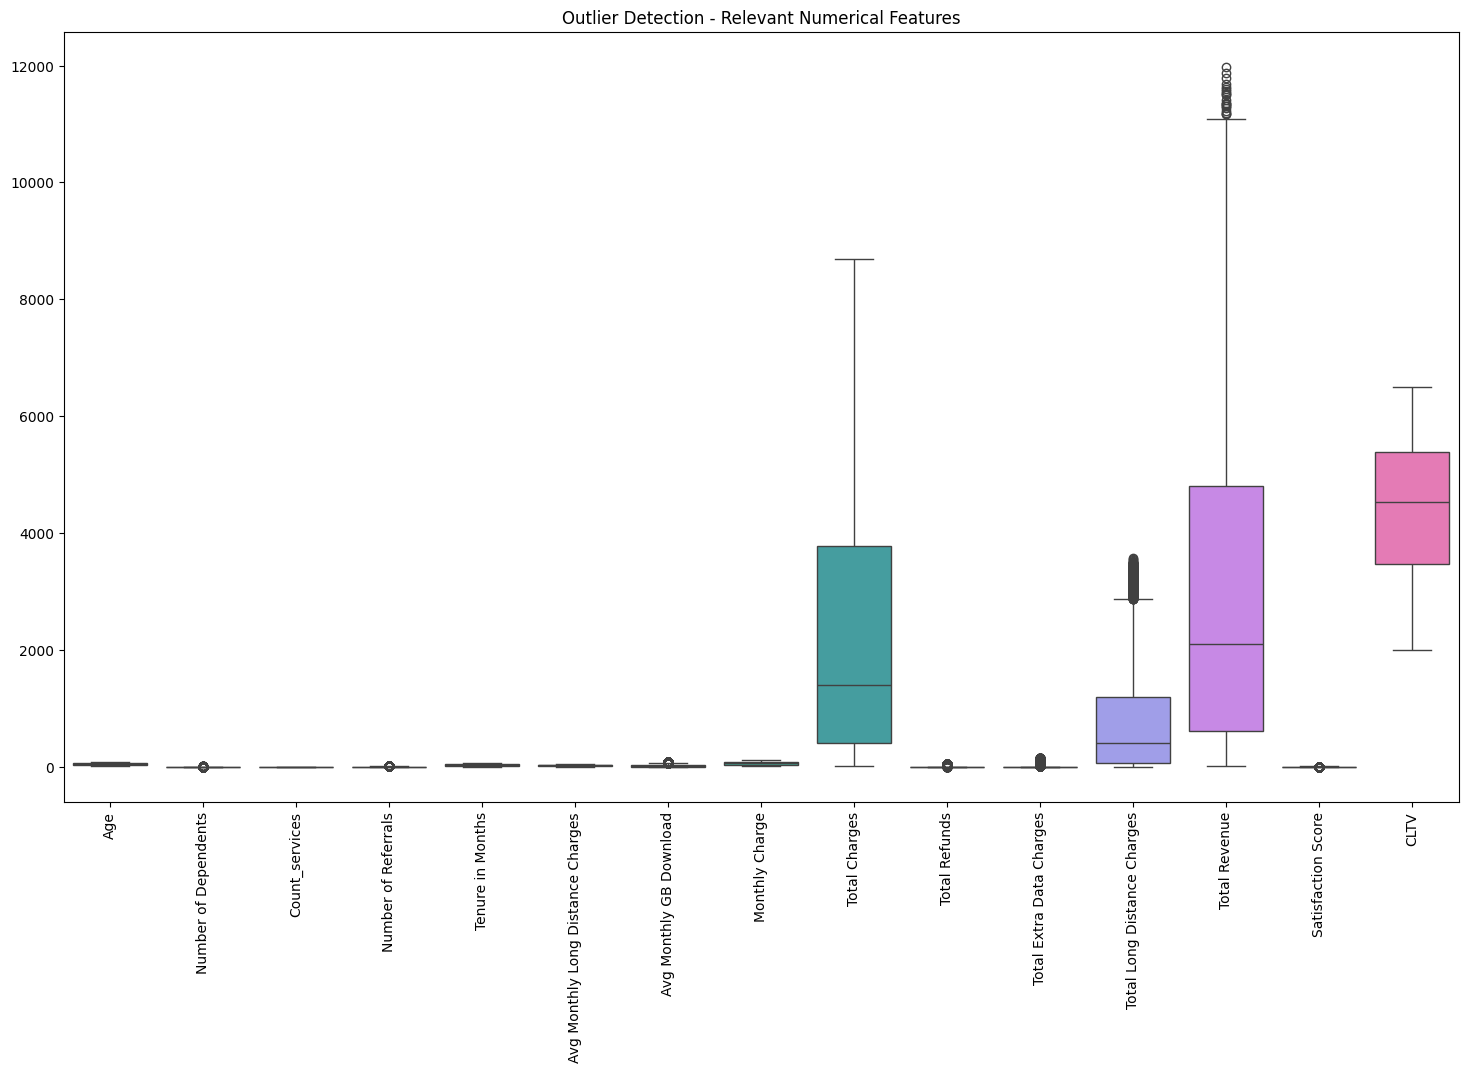

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 10))

sns.boxplot(data=combined[outlier_cols])

plt.xticks(rotation=90)
plt.title("Outlier Detection - Relevant Numerical Features")
plt.savefig("outlier_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
combined['Number of Dependents'].value_counts().sort_index()

Number of Dependents
0    5416
1     553
2     531
3     517
4       9
5      10
6       3
7       2
8       1
9       1
Name: count, dtype: int64

In [18]:
combined['Number of Dependents'].describe()

count    7043.000000
mean        0.468692
std         0.962802
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         9.000000
Name: Number of Dependents, dtype: float64

In [19]:
Q1 = combined['Number of Dependents'].quantile(0.25)
Q3 = combined['Number of Dependents'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)

Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0


In [20]:
outliers = combined[
    (combined['Number of Dependents'] < lower) |
    (combined['Number of Dependents'] > upper)
]

outliers[['Number of Dependents']]

,Number of Dependents
1,1
2,3
3,1
4,1
5,1
...,...
7014,2
7028,1
7039,2
7040,2


In [21]:
combined['Number of Referrals'].value_counts().sort_index()

Number of Referrals
0     3821
1     1086
2      236
3      255
4      236
5      264
6      221
7      248
8      213
9      238
10     223
11       2
Name: count, dtype: int64

In [22]:
combined['Number of Referrals'].describe()

count    7043.000000
mean        1.951867
std         3.001199
min         0.000000
25%         0.000000
50%         0.000000
75%         3.000000
max        11.000000
Name: Number of Referrals, dtype: float64

In [23]:
Q1 = combined['Number of Referrals'].quantile(0.25)
Q3 = combined['Number of Referrals'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)

Q1: 0.0
Q3: 3.0
IQR: 3.0
Lower Bound: -4.5
Upper Bound: 7.5


In [24]:
outliers = combined[
    (combined['Number of Referrals'] < lower) |
    (combined['Number of Referrals'] > upper)
]

outliers[['Number of Referrals']]

,Number of Referrals
253,8
317,9
477,10
480,9
481,9
...,...
6985,10
6995,8
7005,8
7013,9


In [25]:
len(outliers)

676

In [26]:
# Target variable
y = combined['Churn Value']

# Remove columns that should not be used as predictors
X = combined.drop(columns=[
    'Customer ID',
    'Service ID',
    'Status ID',
    'Location ID',
    'Churn Label',
    'Churn Value',
    'Churn Category',
    'Churn Reason',
    'Customer Status'
])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 52)
y shape: (7043,)


In [27]:
# Convert categorical variables into dummy variables
X = pd.get_dummies(X, drop_first=True)

print("X shape after encoding:", X.shape)

X shape after encoding: (7043, 4402)


In [28]:
# Fill missing values
X = X.fillna(0)

print("Missing values:", X.isnull().sum().sum())

Missing values: 0


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 4402)
Testing data: (1409, 4402)


In [30]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Logistic Regression completed successfully!")

Logistic Regression completed successfully!


C:\Users\Aadhi\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9134137686302342

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      1035
           1       0.85      0.82      0.83       374

    accuracy                           0.91      1409
   macro avg       0.89      0.88      0.89      1409
weighted avg       0.91      0.91      0.91      1409


Confusion Matrix:
[[981  54]
 [ 68 306]]


In [32]:
for name, df in {
    "demographics": demographics,
    "services": services,
    "status": status,
    "location": location,
    "population": population
}.items():
    print("\n", name)
    print(df.shape)
    print(df.columns.tolist())


 demographics
(7043, 9)
['Customer ID', 'Count', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents']

 services
(7043, 31)
['Service ID', 'Customer ID', 'Count', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue']

 status
(7043, 12)
['Status ID', 'Customer ID', 'Count', 'Quarter', 'Satisfaction Score', 'Customer Status', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason']

 location
(7043, 10)
['Location ID', 

In [33]:
# Merge demographics + services
df = demographics.merge(
    services,
    on="Customer ID",
    how="inner",
    suffixes=("_demo", "_service")
)

# Merge status
df = df.merge(
    status,
    on="Customer ID",
    how="inner",
    suffixes=("", "_status")
)

# Merge location
df = df.merge(
    location,
    on="Customer ID",
    how="inner",
    suffixes=("", "_location")
)

print("Shape after customer-level merge:", df.shape)

Shape after customer-level merge: (7043, 59)


In [34]:
df = df.merge(
    population,
    on="Zip Code",
    how="left"
)

print("Final shape:", df.shape)

Final shape: (7043, 61)


In [35]:
print(df.columns.tolist())

['Customer ID', 'Count_demo', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Service ID', 'Count_service', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Status ID', 'Count', 'Quarter_status', 'Satisfaction Score', 'Customer Status', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason', 'Location ID', 'Count_location', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'ID', '

In [36]:
print("Duplicate Customer IDs:", df["Customer ID"].duplicated().sum())

Duplicate Customer IDs: 0


In [37]:
target = "Churn Value"

In [38]:
leakage_columns = [
    "Churn Label",
    "Churn Value",
    "Churn Score",
    "Churn Category",
    "Churn Reason",
    "Customer Status"
]

X = df.drop(columns=leakage_columns)
y = df["Churn Value"]

In [39]:
X = X.drop(
    columns=[
        "Customer ID",
        "Service ID",
        "Status ID",
        "Location ID",
        "ID"
    ],
    errors="ignore"
)

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (5634, 50)
Testing: (1409, 50)


In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns

numerical_cols = X_train.select_dtypes(
    exclude=["object"]
).columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        ),
        (
            "num",
            "passthrough",
            numerical_cols
        )
    ]
)

In [42]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

In [43]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](50,)","['Count_demo','Gender','Age',...,'Latitude','Longitude','Population']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,50
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all re

In [45]:
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.9924384510062259

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1035
           1       0.96      0.90      0.93       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409


Confusion Matrix:
[[1022   13]
 [  37  337]]


   Decile  Customers  Churners  Churn_Rate      Lift
0       1        141       141    1.000000  3.767380
1       2        141       141    1.000000  3.767380
2       3        141        75    0.531915  2.003925
3       4        141        15    0.106383  0.400785
4       5        141         2    0.014184  0.053438
5       6        140         0    0.000000  0.000000
6       7        141         0    0.000000  0.000000
7       8        141         0    0.000000  0.000000
8       9        141         0    0.000000  0.000000
9      10        141         0    0.000000  0.000000

Top 10% Lift Score: 3.77


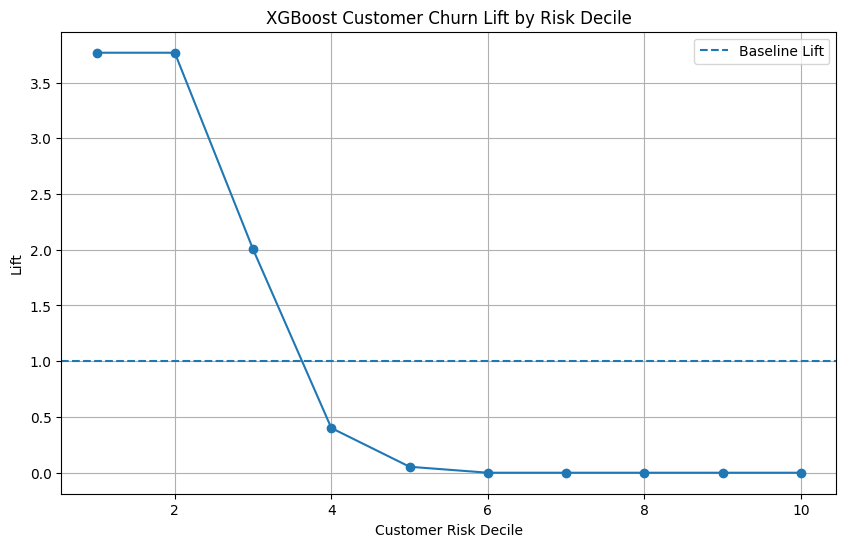

In [46]:
# ============================================
# LIFT SCORE ANALYSIS
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# Create evaluation dataframe
lift_df = pd.DataFrame({
    "Actual Churn": y_test.values,
    "Churn Probability": y_prob
})

# Rank customers from highest to lowest predicted churn probability
lift_df = lift_df.sort_values(
    "Churn Probability",
    ascending=False
).reset_index(drop=True)

# Divide customers into 10 equal-sized groups (deciles)
lift_df["Decile"] = pd.qcut(
    lift_df.index,
    q=10,
    labels=False
) + 1

# Calculate churn rate for each decile
decile_summary = lift_df.groupby("Decile").agg(
    Customers=("Actual Churn", "count"),
    Churners=("Actual Churn", "sum"),
    Churn_Rate=("Actual Churn", "mean")
).reset_index()

# Overall churn rate
overall_churn_rate = lift_df["Actual Churn"].mean()

# Calculate lift
decile_summary["Lift"] = (
    decile_summary["Churn_Rate"] /
    overall_churn_rate
)

print(decile_summary)

# Lift in the top 10% of predicted-risk customers
top_10_lift = decile_summary.loc[
    decile_summary["Decile"] == 1, "Lift"
].iloc[0]

print(f"\nTop 10% Lift Score: {top_10_lift:.2f}")

# Plot lift curve
plt.figure(figsize=(10, 6))

plt.plot(
    decile_summary["Decile"],
    decile_summary["Lift"],
    marker="o"
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Baseline Lift"
)

plt.xlabel("Customer Risk Decile")
plt.ylabel("Lift")
plt.title("XGBoost Customer Churn Lift by Risk Decile")
plt.legend()
plt.grid(True)
plt.show()

Top 20 features influencing churn prediction:


,Feature,Importance
0,num__Satisfaction Score,0.243580
1,cat__Contract_Month-to-Month,0.103100
2,cat__Online Security_Yes,0.070338
3,cat__Internet Service_No,0.066312
4,cat__Internet Service_Yes,0.055966
5,cat__Senior Citizen_No,0.043420
6,cat__Online Security_No,0.038336
7,cat__Internet Type_Fiber Optic,0.034364
8,num__Number of Referrals,0.022154
9,cat__City_San Diego,0.015158


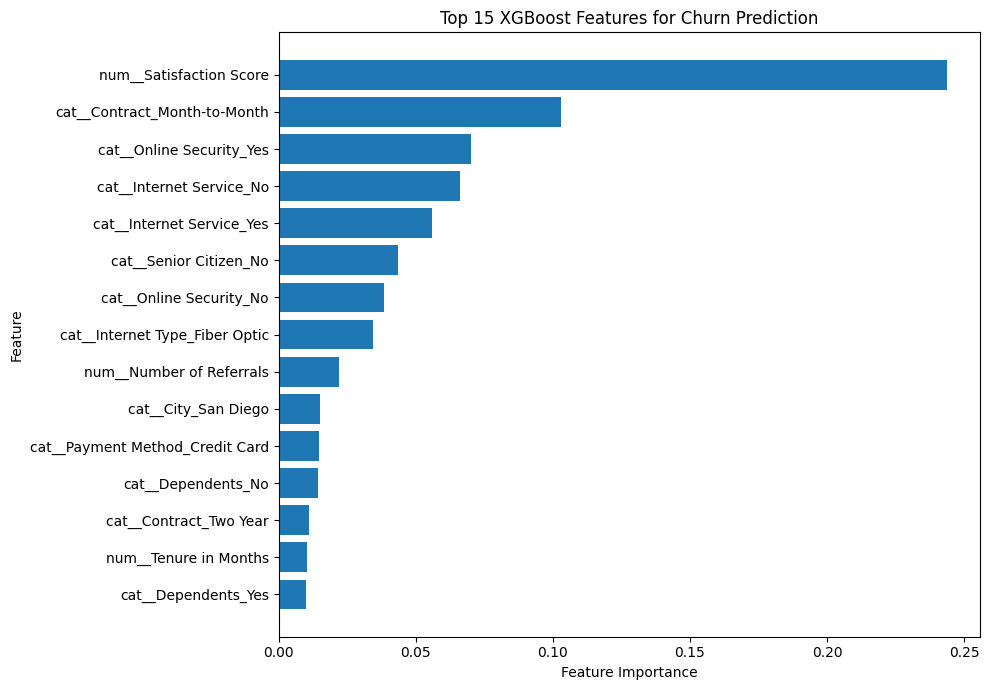

In [47]:
# ============================================
# XGBOOST FEATURE IMPORTANCE
# ============================================

# Get feature names after preprocessing
feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get XGBoost feature importance
importance_values = pipeline.named_steps[
    "model"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort from most to least important
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

# Display top 20 features
print("Top 20 features influencing churn prediction:")
display(feature_importance.head(20))

# Plot top 15
top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Features for Churn Prediction")
plt.tight_layout()
plt.show()

In [48]:
# ============================================
# CUSTOMER CLV AT RISK
# ============================================

# Match the test-set customers back to the original dataframe
clv_results = df.loc[
    X_test.index,
    ["Customer ID", "CLTV"]
].copy()

clv_results["Actual Churn"] = y_test
clv_results["Churn Probability"] = y_prob
clv_results["Predicted Churn"] = y_pred

# Rank by predicted churn probability
clv_results = clv_results.sort_values(
    "Churn Probability",
    ascending=False
)

# Customers predicted to churn
predicted_churners = clv_results[
    clv_results["Predicted Churn"] == 1
].copy()

# Total CLTV represented by predicted churners
clv_at_risk = predicted_churners["CLTV"].sum()

print(
    f"Number of customers predicted to churn: "
    f"{len(predicted_churners)}"
)

print(
    f"Total CLTV at risk among predicted churners: "
    f"${clv_at_risk:,.2f}"
)

print("\nTop 10 highest-risk customers:")
display(
    predicted_churners[
        [
            "Customer ID",
            "Churn Probability",
            "CLTV",
            "Actual Churn"
        ]
    ].head(10)
)

Number of customers predicted to churn: 350
Total CLTV at risk among predicted churners: $1,464,203.00

Top 10 highest-risk customers:


,Customer ID,Churn Probability,CLTV,Actual Churn
2023,7908-QCBCA,0.999882,2404,1
397,9912-GVSEQ,0.999871,2591,1
124,4514-GFCFI,0.999852,5136,1
75,4086-YQSNZ,0.999844,3834,1
1772,0895-DQHEW,0.999814,4019,1
1271,1448-PWKYE,0.999800,2046,1
63,1374-DMZUI,0.999796,5419,1
1328,7294-TMAOP,0.999790,2627,1
2000,8642-GVWRF,0.999785,3039,1
387,1363-TXLSL,0.999780,4962,1


In [49]:
# ============================================
# ESTIMATED CLV SAVED UNDER RETENTION SCENARIOS
# ============================================

retention_rates = [0.10, 0.20, 0.30, 0.50]

clv_scenarios = pd.DataFrame({
    "Assumed Retention Success Rate": retention_rates
})

clv_scenarios["Estimated CLV Saved"] = (
    clv_at_risk *
    clv_scenarios["Assumed Retention Success Rate"]
)

print("Estimated CLV saved under different retention-success assumptions:")
display(clv_scenarios)

Estimated CLV saved under different retention-success assumptions:


,Assumed Retention Success Rate,Estimated CLV Saved
0,0.1,146420.3
1,0.2,292840.6
2,0.3,439260.9
3,0.5,732101.5


In [50]:
import joblib

joblib.dump(
    pipeline,
    "telco_churn_xgboost.pkl"
)

print("Model saved successfully!")

Model saved successfully!
